# TME 2 - Gradient Descent 

Gradient descent - is an optimization algorithm to minimize a funtion by iteratively moving in the direction of the minimum (if the convex function).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
#from mltools import plot_data, plot_frontiere, make_grid, gen_arti
#had a problem with importing mltools, so I copied the functions here

def plot_data(data,labels=None):
    """
    Affiche des donnees 2D
    :param data: matrice des donnees 2d
    :param labels: vecteur des labels (discrets)
    :return:
    """
    if labels is not None:
        labels = labels.reshape(-1)
    cols,marks = ["red", "green", "blue", "orange", "black", "cyan"],[".","+","*","o","x","^"]
    if labels is None:
        plt.scatter(data[:,0],data[:,1],marker="x")
        return
    for i,l in enumerate(sorted(list(set(labels.flatten())))):
        plt.scatter(data[labels==l,0],data[labels==l,1],c=cols[i],marker=marks[i])

def plot_frontiere(data,f,step=20):
    """ Trace un graphe de la frontiere de decision de f
    :param data: donnees
    :param f: fonction de decision
    :param step: pas de la grille
    :return:
    """
    grid,x,y=make_grid(data=data,step=step)
    plt.contourf(x,y,f(grid).reshape(x.shape),colors=('gray','blue'),levels=[-1,0,1])

def make_grid(data=None,xmin=-5,xmax=5,ymin=-5,ymax=5,step=20):
    """ Cree une grille sous forme de matrice 2d de la liste des points
    :param data: pour calcluler les bornes du graphe
    :param xmin: si pas data, alors bornes du graphe
    :param xmax:
    :param ymin:
    :param ymax:
    :param step: pas de la grille
    :return: une matrice 2d contenant les points de la grille
    """
    if data is not None:
        xmax, xmin, ymax, ymin = np.max(data[:,0]),  np.min(data[:,0]), np.max(data[:,1]), np.min(data[:,1])
    x, y =np.meshgrid(np.arange(xmin,xmax,(xmax-xmin)*1./step), np.arange(ymin,ymax,(ymax-ymin)*1./step))
    grid=np.c_[x.ravel(),y.ravel()]
    return grid, x, y

def gen_arti(centerx=1,centery=1,sigma=0.1,nbex=1000,data_type=0,epsilon=0.02):
    """ Generateur de donnees,
        :param centerx: centre des gaussiennes
        :param centery:
        :param sigma: des gaussiennes
        :param nbex: nombre d'exemples
        :param data_type: 0: melange 2 gaussiennes, 1: melange 4 gaussiennes, 2:echequier
        :param epsilon: bruit dans les donnees
        :return: data matrice 2d des donnnes,y etiquette des donnnees
    """
    if data_type==0:
         #melange de 2 gaussiennes
         xpos=np.random.multivariate_normal([centerx,centerx],np.diag([sigma,sigma]),nbex//2)
         xneg=np.random.multivariate_normal([-centerx,-centerx],np.diag([sigma,sigma]),nbex//2)
         data=np.vstack((xpos,xneg))
         y=np.hstack((np.ones(nbex//2),-np.ones(nbex//2)))
    if data_type==1:
        #melange de 4 gaussiennes
        xpos=np.vstack((np.random.multivariate_normal([centerx,centerx],np.diag([sigma,sigma]),nbex//4),np.random.multivariate_normal([-centerx,-centerx],np.diag([sigma,sigma]),nbex//4)))
        xneg=np.vstack((np.random.multivariate_normal([-centerx,centerx],np.diag([sigma,sigma]),nbex//4),np.random.multivariate_normal([centerx,-centerx],np.diag([sigma,sigma]),nbex//4)))
        data=np.vstack((xpos,xneg))
        y=np.hstack((np.ones(nbex//2),-np.ones(nbex//2)))

    if data_type==2:
        #echiquier
        data=np.reshape(np.random.uniform(-4,4,2*nbex),(nbex,2))
        y=np.ceil(data[:,0])+np.ceil(data[:,1])
        y=2*(y % 2)-1
    # un peu de bruit
    data[:,0]+=np.random.normal(0,epsilon,nbex)
    data[:,1]+=np.random.normal(0,epsilon,nbex)
    # on mélange les données
    idx = np.random.permutation((range(y.size)))
    data=data[idx,:]
    y=y[idx]
    return data,y.reshape(-1, 1)

gen_arti(data_type=0)

(array([[-0.97618661, -1.12070775],
        [-1.09002548, -1.47959521],
        [ 0.78434258,  0.78519965],
        ...,
        [-0.46473905, -1.02972455],
        [-0.80988435, -1.29137681],
        [ 1.28139199,  1.3819297 ]]),
 array([[-1.],
        [-1.],
        [ 1.],
        [ 1.],
        [-1.],
        [ 1.],
        [-1.],
        [ 1.],
        [-1.],
        [ 1.],
        [-1.],
        [ 1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [ 1.],
        [ 1.],
        [-1.],
        [ 1.],
        [-1.],
        [ 1.],
        [-1.],
        [ 1.],
        [-1.],
        [-1.],
        [-1.],
        [ 1.],
        [ 1.],
        [ 1.],
        [ 1.],
        [ 1.],
        [-1.],
        [ 1.],
        [-1.],
        [-1.],
        [ 1.],
        [-1.],
        [-1.],
        [ 1.],
        [ 1.],
        [-1.],
        [ 1.],
        [-1.],
        [ 1.],
        [ 1.],
        [ 1.],
        [ 1.],
        [-1.],
        [ 1.],
        [-1.],
    

## Implement cost functions

1. mean sqaured error - difference between predicted and true output
2. logistic regression cost - we get the probability of being the other class than true class, we want to maximize the probability of being the true class and minimize the rest

In [3]:

def mse(w,x,y):
    y = y.reshape(-1,1)
    w = w.reshape(-1,1)
    x = x.reshape(y.shape[0],w.shape[0])
    mse = (y - x @ w )**2
    return mse

def mse_grad(w,x,y):
    y = y.reshape(-1,1)
    w = w.reshape(-1,1)
    x = x.reshape(y.shape[0],w.shape[0])
    gradient = -2*(y - x @ w )*x
    return gradient

def reglog(w,x,y):
    y = y.reshape(-1,1)
    w = w.reshape(-1,1)
    x = x.reshape(y.shape[0],w.shape[0])
    loss = np.log(1 + np.exp(-y * (x@w)))
    return loss

def reglog_grad(w,x,y):
    y = y.reshape(-1,1)
    w = w.reshape(-1,1)
    x = x.reshape(y.shape[0],w.shape[0])
    gradient_ll = (-y *x/ (1 + np.exp(y * (x@w))))
    return gradient_ll

In [4]:
def check_fonctions():
    ## On fixe la seed de l'aléatoire pour vérifier les fonctions
    np.random.seed(0)
    datax, datay = gen_arti(epsilon=0.1)
    wrandom = np.random.randn(datax.shape[1],1)
    assert(np.isclose(mse(wrandom,datax,datay).mean(),0.54731,rtol=1e-4))
    assert(np.isclose(reglog(wrandom,datax,datay).mean(), 0.57053,rtol=1e-4))
    assert(np.isclose(mse_grad(wrandom,datax,datay).mean(),-1.43120,rtol=1e-4))
    assert(np.isclose(reglog_grad(wrandom,datax,datay).mean(),-0.42714,rtol=1e-4))
    np.random.seed()


In [5]:
def descente_gradient(datax,datay,f_loss,f_grad,eps,iter):
    w = np.random.randn(datax.shape[1],1)
    datay = datay.reshape(-1, 1)
    cost = f_loss(w,datax,datay)
    weights = [w.copy()]
    costs= [np.mean(cost)]

    for i in range(iter):
        grad = f_grad(w,datax,datay)
        grad_mean = np.mean(grad, axis=0).reshape(-1, 1)
        w = w - eps*grad_mean
        weights.append(w)
        costs.append(np.mean(f_loss(w,datax,datay)))

    
    return w, weights, costs

## Experiments 

### Linear regression vs Logistic regresssion

In this case our data is linearly seperable. We compare how two models claasify the data. Decision boundary will indicate the distinction between classes. We consider different weights based on the given loss functions (mse vs logreg). They will create a decision boundary.

In [6]:

data_x,data_y = gen_arti(nbex=1000,data_type=0)

#linear function
w_mse,weights_mse, cost_mse = descente_gradient(data_x, data_y, mse, mse_grad, eps=0.01, iter=100)
#logistic function
w_log,weights_log, cost_log = descente_gradient(data_x, data_y, reglog, reglog_grad, eps=0.01, iter=100)


Text(0.5, 1.0, 'Decision boundary for Logistic Regression')

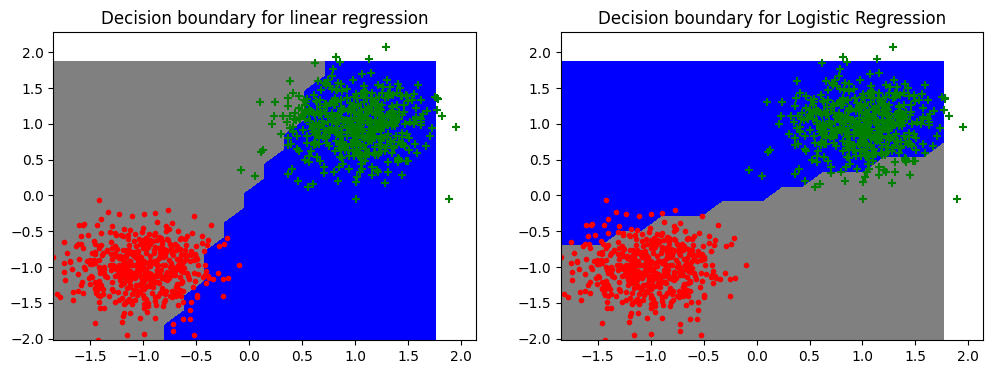

In [7]:
plt.figure(figsize=(12, 4))
subplot = plt.subplot(1,2,1)
plot_frontiere(data_x,lambda x: np.sign(x @ w_mse),step=20)
plot_data(data_x,data_y)
plt.title("Decision boundary for linear regression")
plt.subplot(1, 2, 2)  
plot_frontiere(data_x, lambda x: np.sign(x @ w_log), step=20)
plot_data(data_x, data_y) 
plt.title("Decision boundary for Logistic Regression")




Cost evolution

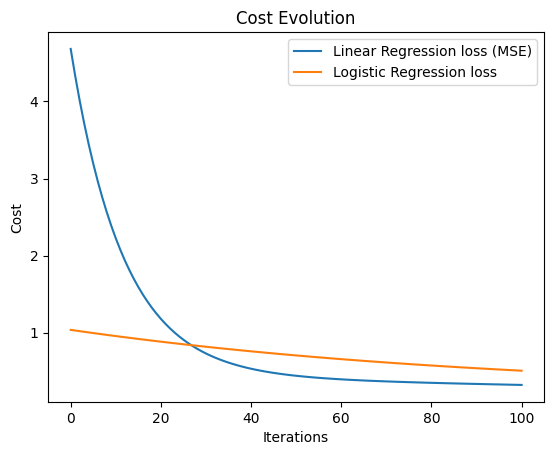

In [8]:
plt.plot(cost_mse, label="Linear Regression loss (MSE)")
plt.plot(cost_log, label="Logistic Regression loss")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Evolution")
plt.legend()

### Results 

We can observe that both models classify the data quite well. They draw different decision boundaries but both are 'correct'. It is hard to choose only one model based on the decision boundaries, their performance depends on the data distribution. We assume they is no significant difference between two models. 

Looking at the qunatitative performance we see that cost is larger for logistic regression loss compared to MSE. However, again the values are relatively close to each other. We can also observe that the cost is decreasing with more iterations which is in line with expectations as the model learns more optimal weights. 

## Learning rate influence

epsilon - learning rate. Hyperparameter that can influence learning, by controlling the adjustement of weights during the process. We would expect that when small learning rate the weights are adjusted slower than with high values for learning rate. However, with too high learning rate the learning may overshoot missing the optimal solution.

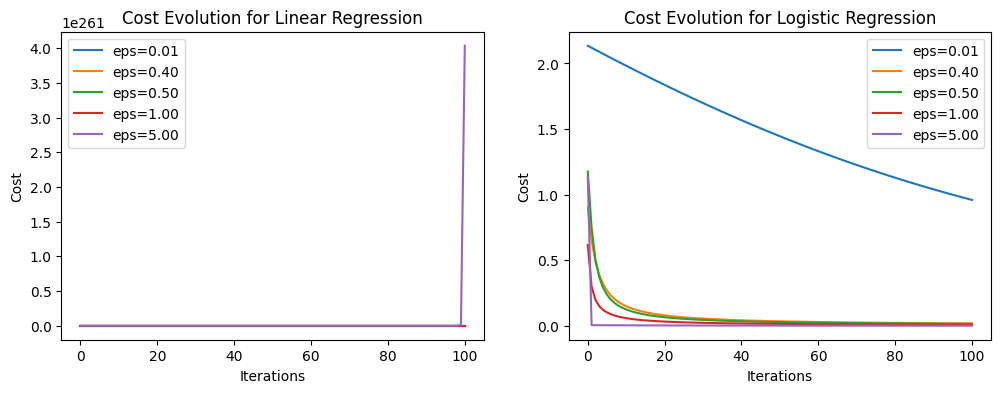

In [9]:
epsilon = [0.01,0.4, 0.5, 1, 5]
plt.figure(figsize=(12, 4))
for eps in epsilon:
    w_mse,weights_mse, cost_mse = descente_gradient(data_x, data_y, mse, mse_grad, eps=eps, iter=100)
    w_log,weights_log, cost_log = descente_gradient(data_x, data_y, reglog, reglog_grad, eps=eps, iter=100)

    plt.subplot(1,2,1)
    plt.plot(cost_mse,label="eps=%.2f"%eps)
    plt.xlabel("Iterations")
    plt.ylabel("Cost")
    plt.title("Cost Evolution for Linear Regression")
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(cost_log,label="eps=%.2f"%eps)
    plt.xlabel("Iterations")
    plt.ylabel("Cost")
    plt.title("Cost Evolution for Logistic Regression")
    plt.legend()

plt.show()

### Results 

Linear regression cost (mse) - we can observe that for small learning rate (0.001 - 0.4) the cost decrease quickly reaching converegence to 0. However, with learning rate above or equal to 0.5 the cost raises later in time (90 iterations), might be due to overshooting (speculation). 

Logistic regression cost (logreg) - here the cost always decrease even with high learning rate values. The higher the learning rate the faster the convergence. With very small learnign rate we observe flatter function, however still decreasing. 

We can interpret those results as logistic regression being less sensitive to learning rate. 

## Non separable data 

- we add noise to the data to make it non separable. Given linear model we would expect worse performance for non-separable data than separable data. 

Text(0.5, 1.0, 'Decision boundary for Logistic Regression')

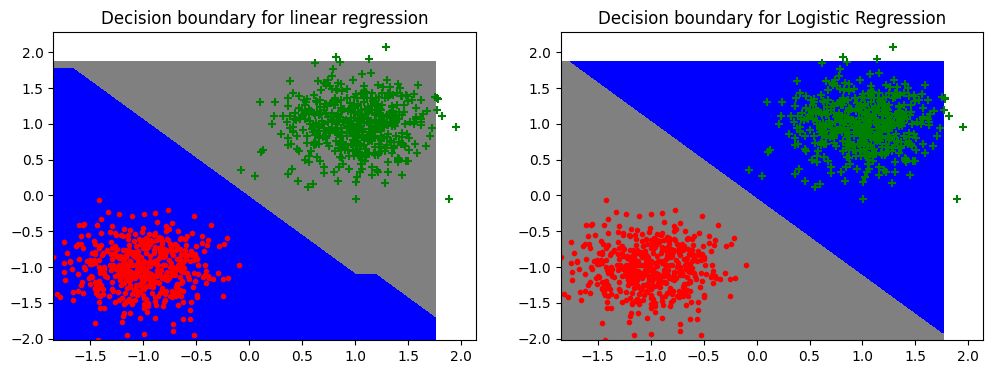

In [10]:
plt.figure(figsize=(12, 4))
subplot = plt.subplot(1,2,1)
plot_frontiere(data_x,lambda x: np.sign(x @ w_mse),step=20)
plot_data(data_x,data_y)
plt.title("Decision boundary for linear regression")
plt.subplot(1, 2, 2)  
plot_frontiere(data_x, lambda x: np.sign(x @ w_log), step=20)
plot_data(data_x, data_y) 
plt.title("Decision boundary for Logistic Regression")




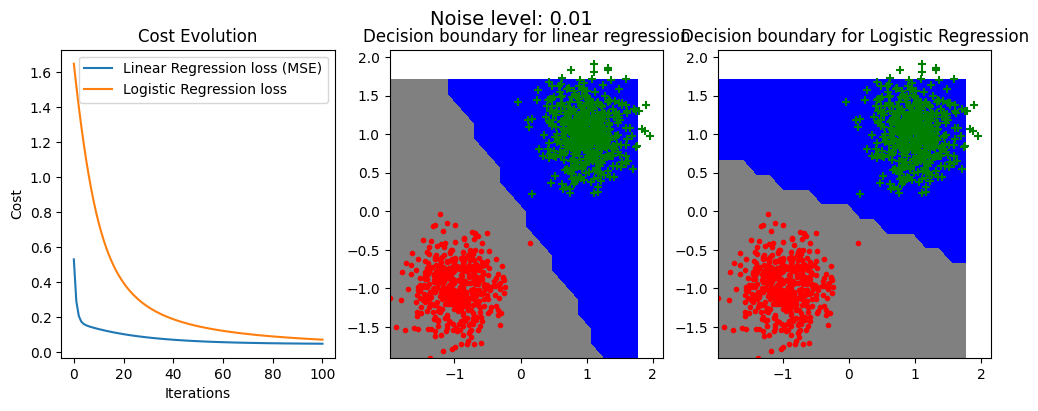

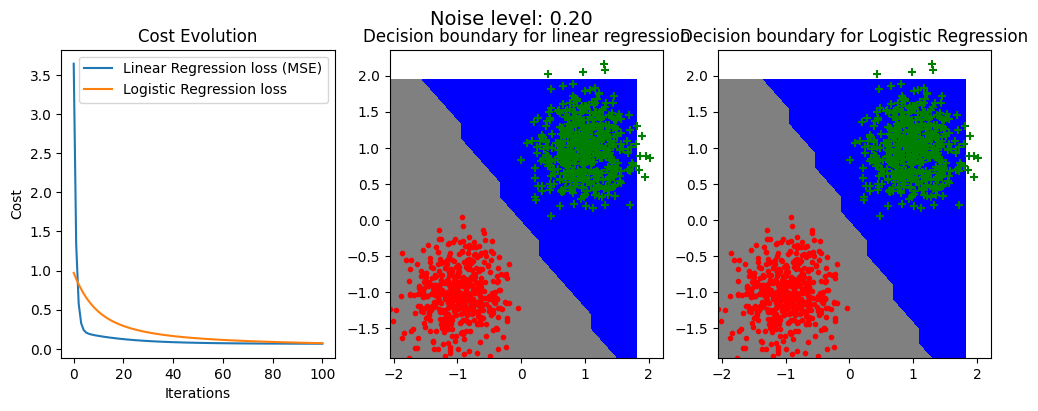

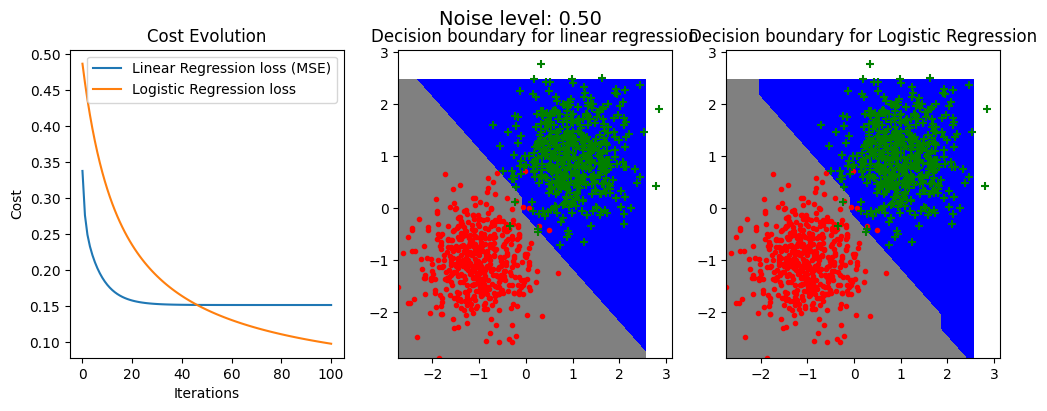

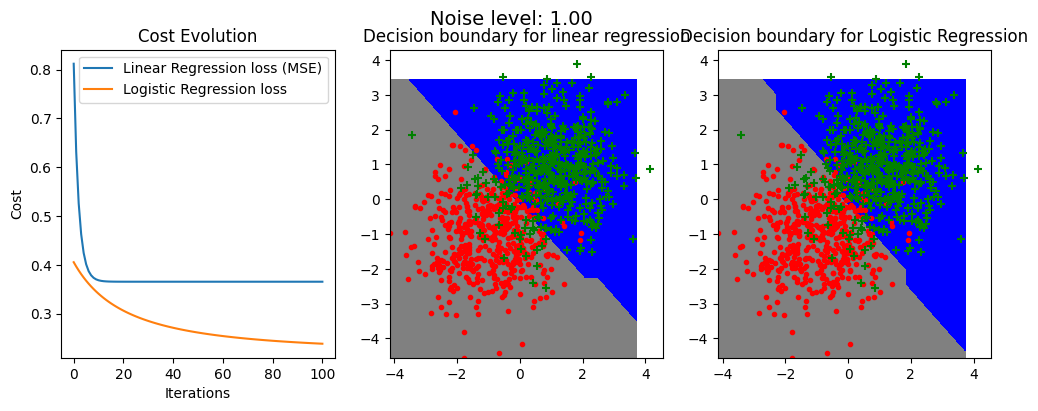

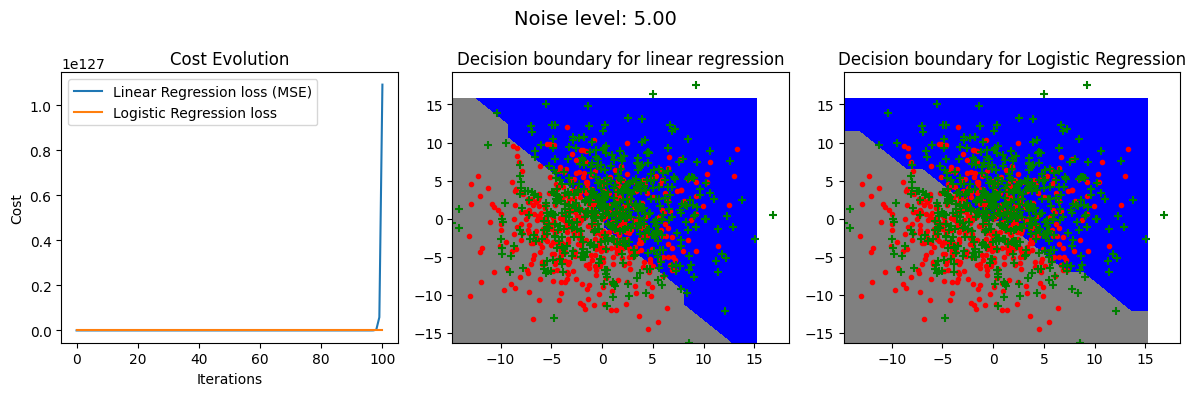

In [15]:
import matplotlib.pyplot as plt

noise_levels = [0.01, 0.2, 0.5, 1,5]
for e in noise_levels:
    data_x, data_y = gen_arti(nbex=1000, data_type=0, epsilon=e)

    w_mse, weights_mse, cost_mse = descente_gradient(data_x, data_y, mse, mse_grad, eps=0.1, iter=100)
    w_log, weights_log, cost_log = descente_gradient(data_x, data_y, reglog, reglog_grad, eps=0.1, iter=100)

    plt.figure(figsize=(12, 4))
    plt.suptitle("Noise level: %.2f" % e, fontsize=14)
    plt.subplot(1,3,1)
    plt.plot(cost_mse, label="Linear Regression loss (MSE)")
    plt.plot(cost_log, label="Logistic Regression loss")
    plt.xlabel("Iterations")
    plt.ylabel("Cost")
    plt.title("Cost Evolution")
    plt.legend()
    plt.subplot(1,3,2)
    plot_frontiere(data_x,lambda x: np.sign(x @ w_mse),step=20)
    plot_data(data_x,data_y)
    plt.title("Decision boundary for linear regression")
    plt.subplot(1, 3, 3)  
    plot_frontiere(data_x, lambda x: np.sign(x @ w_log), step=20)
    plot_data(data_x, data_y) 
    plt.title("Decision boundary for Logistic Regression")

plt.tight_layout()
plt.show()


### Results 

We can observe how the decision boundary changes with data. However, here we can observe it works very well with separable data, but fails with non separable data. Models are not flexible enough to produce other decision boundaries than linear. We can observe that for data with medium levels of noise the cost does not converge to 0 but slightly above. How data with a lot of noise the cost increases (possibly indefinitely) after 90 iterations. 
Those results nicely show the limitation of linear and logistic regression as a classifier having only linear decision boundaries. 

## Weight space and trajectory of change 

Visualizing the trajectorise helps us to understand how the weights change to find the minimum of the function.

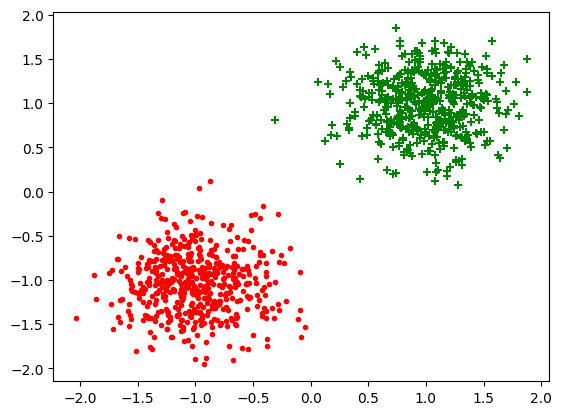

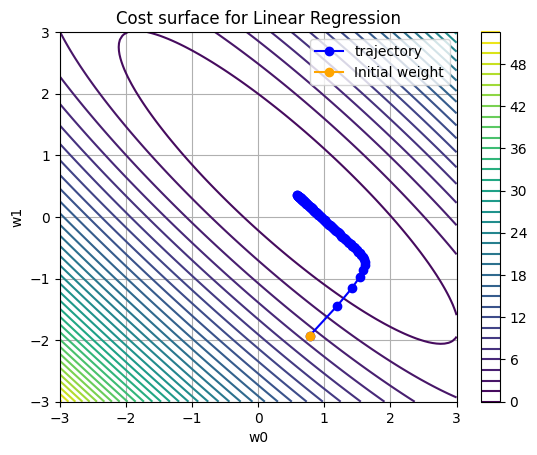

In [12]:
data_x, data_y = gen_arti(nbex=1000, data_type=0, epsilon=0.1)
w_mse, weights_mse, cost_mse = descente_gradient(data_x, data_y, mse, mse_grad, eps=0.1, iter=100)
plot_data(data_x,data_y)
w0,w1 = np.meshgrid( np.linspace(-3, 3, 100),  np.linspace(-3, 3, 100))
cost = np.zeros(w0.shape)

for i in range(w0.shape[0]):
    for d in range(w0.shape[1]):
        w = np.array([[w0[i,d]],[w1[i,d]]])
        cost[i,d] = np.mean(mse(w, data_x, data_y))

fig = plt.figure()
contour = plt.contour(w0,w1,cost,levels=50,cmap="viridis")
plt.colorbar(contour)
plt.title("Cost surface for Linear Regression")
plt.xlabel("w0")
plt.ylabel("w1")

weights_np = np.array(weights_mse).squeeze()
plt.plot(weights_np[:, 0], weights_np[:, 1], marker='o', color='blue', label='trajectory')
initial_weight = weights_mse[0]  
plt.plot(initial_weight[0], initial_weight[1], marker='o', color='orange', label='Initial weight')

plt.legend()
plt.grid(True)
plt.show()

We can observe that each time we run the code the initial weight and trajectory changes. This is because we start at different intial point each time and descent toward the minimum. We can observe the cumulation of point in the center, if the reach the minimum they do not move anymore. We can further observe that the way to the minimum is the shortest possible way. This is beacuse we are moving in the direction of the steepest descent, which is also orthogonal to the contours of the cost function. 

## Exploring other types of data 

We can generate different types of data to further explore the performance of our models. 

### Logistic regression

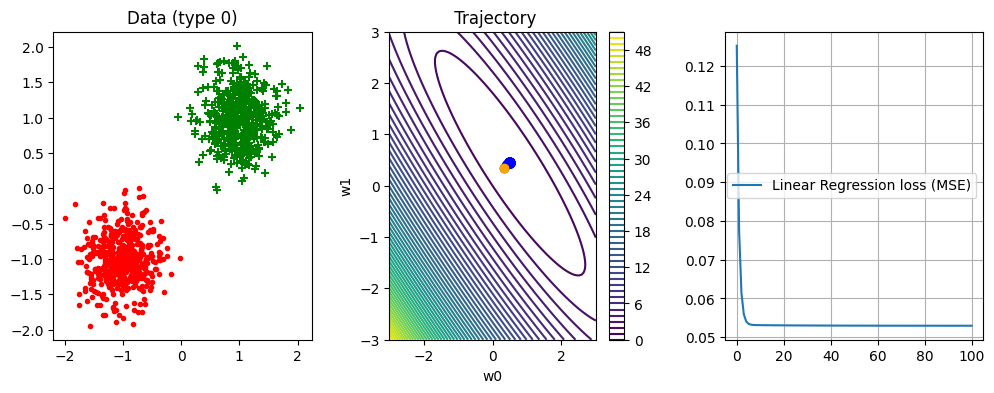

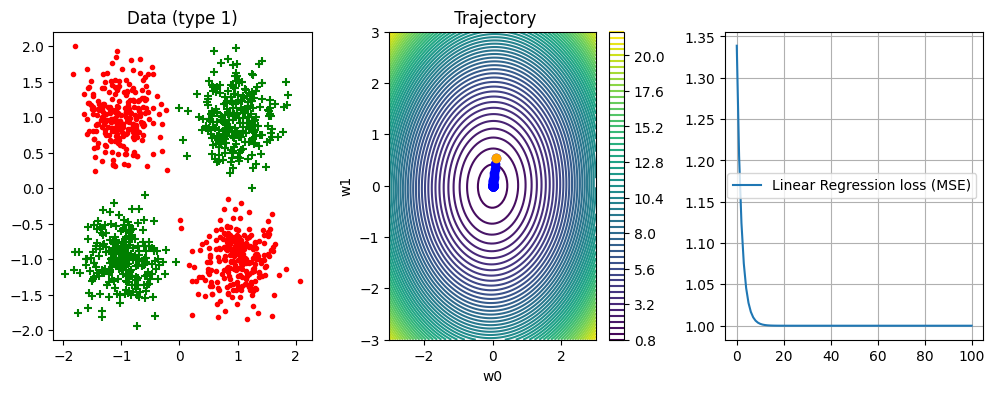

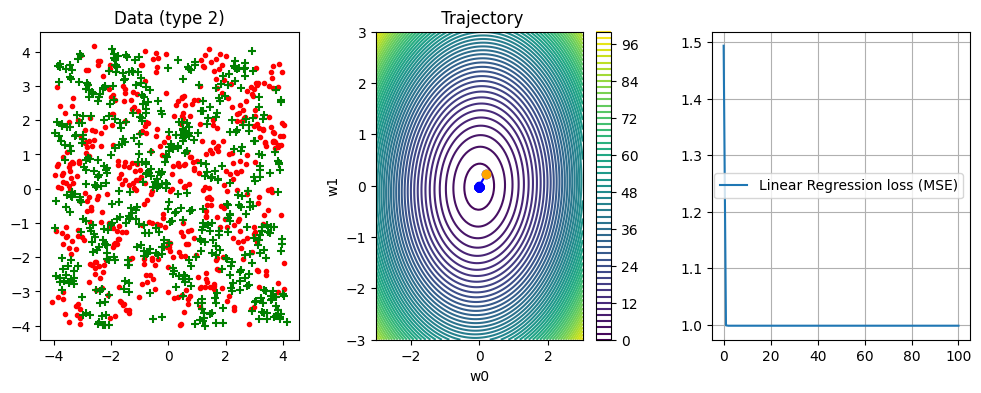

In [13]:
data_type = [0,1,2]
for dtype in data_type:
    data_x, data_y = gen_arti(nbex=1000, data_type=dtype, epsilon=0.1)
    w_mse, weights_mse, cost_mse = descente_gradient(data_x, data_y, mse, mse_grad, eps=0.1, iter=100)
    w0,w1 = np.meshgrid( np.linspace(-3, 3, 100),  np.linspace(-3, 3, 100))
    cost = np.zeros(w0.shape)

    for i in range(w0.shape[0]):
        for d in range(w0.shape[1]):
            w = np.array([[w0[i,d]],[w1[i,d]]])
            cost[i,d] = np.mean(mse(w, data_x, data_y))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plot_data(data_x, data_y)
    plt.title(f'Data (type {dtype})')
    
    plt.subplot(1, 3, 2)
    contour = plt.contour(w0, w1, cost, levels=50, cmap="viridis")
    plt.colorbar(contour)
    plt.title(" Trajectory")
    plt.xlabel("w0")
    plt.ylabel("w1")

    weights_np = np.array(weights_mse).squeeze()
    plt.plot(weights_np[:, 0], weights_np[:, 1], marker='o', color='blue', label='Trajectory')
    initial_weight = weights_mse[0]  
    plt.plot(initial_weight[0], initial_weight[1], marker='o', color='orange', label='Initial weight')

    plt.subplot(1, 3, 3)
    plt.plot(cost_mse, label="Linear Regression loss (MSE)")
    plt.legend()
    plt.grid(True)

    plt.subplots_adjust(wspace=0.3, hspace=0.3)  
    plt.show()

### Results

We can observe how loss function changes with data, we do no see much change. Loss function is relatively similar with more noisy data or non-linearly separable data. Cost goes down, however it is not really meaningful with classification. With noisier or non separable data the cost do not converge to 0.

### Logistic regression

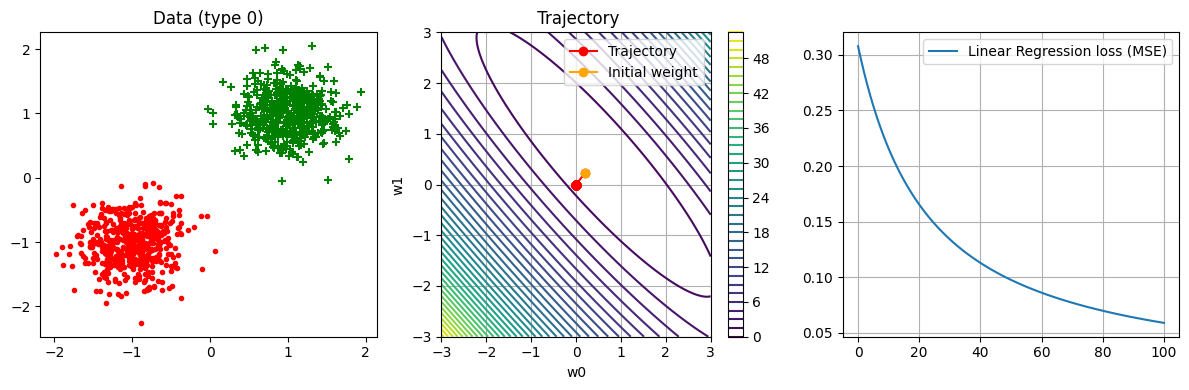

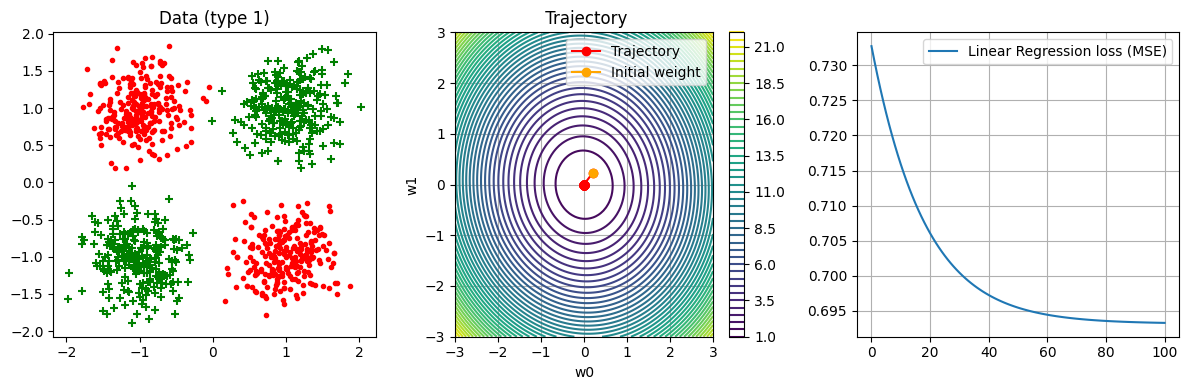

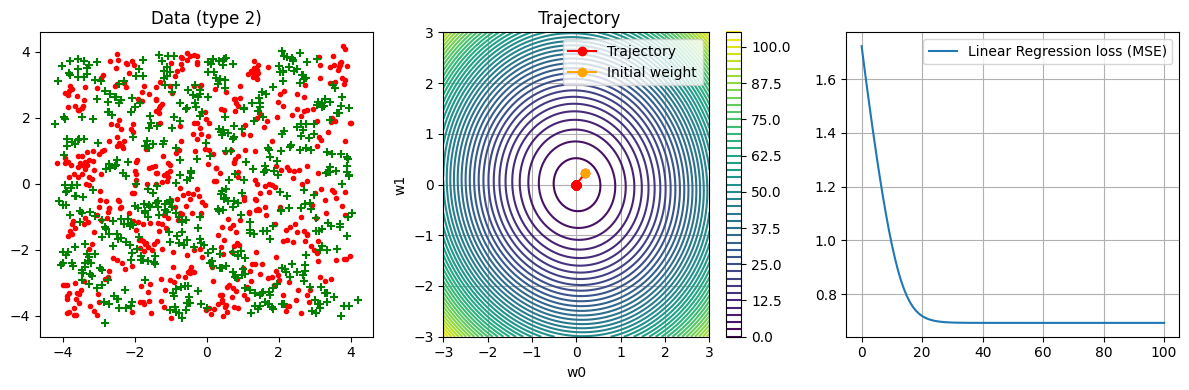

In [14]:
data_type = [0,1,2]
for dtype in data_type:
    data_x, data_y = gen_arti(nbex=1000, data_type=dtype, epsilon=0.1)
    w_log, weights_log, cost_log = descente_gradient(data_x, data_y, reglog, reglog_grad, eps=0.1, iter=100)
    w0,w1 = np.meshgrid( np.linspace(-3, 3, 100),  np.linspace(-3, 3, 100))
    cost = np.zeros(w0.shape)

    for i in range(w0.shape[0]):
        for d in range(w0.shape[1]):
            w = np.array([[w0[i,d]],[w1[i,d]]])
            cost[i,d] = np.mean(mse(w, data_x, data_y))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plot_data(data_x, data_y)
    plt.title(f'Data (type {dtype})')
    
    plt.subplot(1, 3, 2)
    contour = plt.contour(w0, w1, cost, levels=50, cmap="viridis")
    plt.colorbar(contour)
    plt.title(" Trajectory")
    plt.xlabel("w0")
    plt.ylabel("w1")

    weights_np = np.array(weights_mse).squeeze()
    plt.plot(weights_np[:, 0], weights_np[:, 1], marker='o', color='red', label='Trajectory')
    initial_weight = weights_mse[0]  
    plt.plot(initial_weight[0], initial_weight[1], marker='o', color='orange', label='Initial weight')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(cost_log, label="Linear Regression loss (MSE)")
    plt.legend()
    plt.grid(True)

    
    plt.tight_layout()
    plt.show()

## Results

In the case of logistic regression we can observe similar behavior as with the linear regression. Cost decrease slower than in the case of linear regression. Again, no convergence to 0. 